# POC Analysis — Supplier Data Matching & Quality Review

So the idea here is pretty straightforward: a procurement team from a manufacturing company sent us a list of aproximately 592 suppliers. Each one went through Veridion's matching engine and came back with up to 5 candidate matches.

My job was to:
1. Go through every single one and pick the right match (or flag it as unmatched if nothing fits)
2. Look at the data we'd actually deliver and check if it's clean enough to be useful
3. Figure out how well this data supports what the client actually needs: spend analysis, cost savings, and eventually some sustainability stuff

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# loading both sheets
raw = pd.read_excel('presales_data_sample.xlsx', sheet_name='presales_data_sample')
work = pd.read_excel('presales_data_sample.xlsx', sheet_name='Working Data Sample')

# just the ones I picked as correct matches
matched = work[work['best_match'] == 'Y'].copy()

print(f"Total candidates in raw data: {len(raw)}")
print(f"Unique input companies: {work['input_row_key'].nunique()}")
print(f"Companies I matched: {len(matched)}")
print(f"Left unmatched: {work['input_row_key'].nunique() - len(matched)}")

Total candidates in raw data: 2951
Unique input companies: 592
Companies I matched: 498
Left unmatched: 94


## Entity Resolution

The first 100 companies I matched entirely by hand — checking each candidate, googling, verifying addresses. It worked fine but was way too slow for 592 entries.

I found rapidfuzz (a fuzzy string matching library) and built a scoring script that ranked candidates automatically based on:
- **Company name similarity (40%)** 
- **Country match (35%)** 
- **City similarity (15%)**
- **Street similarity (10%)**

Before comparing names I stripped legal suffixes (A/S, Ltd, Sdn Bhd, GmbH, etc.) since they just add noise to the comparison.

The script put each match into one of four buckets: HIGH (name ≥ 0.80 + country match + total ≥ 0.75), MEDIUM (name ≥ 0.65 + country match), REVIEW (total ≥ 0.55), or NO MATCH.

But I didn't trust it blindly. I went through every result and checked manually. And it's a good thing I did. Some high-scoring matches were completely wrong (different companies sharing the same address), and some low-scoring ones turned out to be correct (rebrands like Telenor into Yettel, or abbreviations like DET NORSKE VERITAS into DNV).

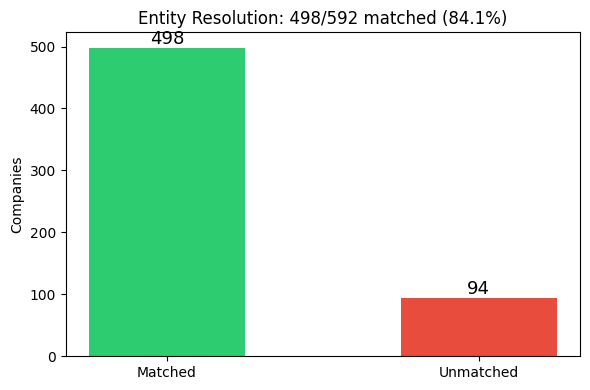

In [3]:
# match rate
total = work['input_row_key'].nunique()
matched_n = len(matched)
unmatched_n = total - matched_n

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Matched', 'Unmatched'], [matched_n, unmatched_n],
              color=['#2ecc71', '#e74c3c'], width=0.5)
ax.bar_label(bars, fmt='%d', fontsize=13)
ax.set_ylabel('Companies')
ax.set_title(f'Entity Resolution: {matched_n}/{total} matched ({matched_n/total*100:.1f}%)')
plt.tight_layout()
plt.show()

## Data Quality Assessment

Now that the matching is done, the question is: can the client actually use this data? I looked at three things — how complete it is, whether the values make sense, and if anything contradicts itself.

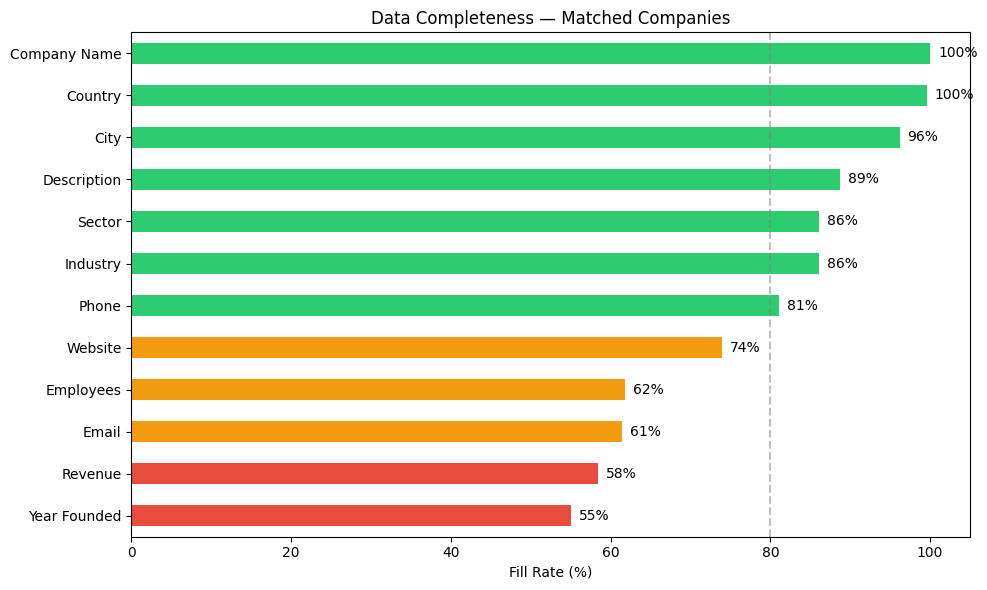

In [4]:
# fill rates for the fields that actually matter for procurement
important_fields = {
    'company_name': 'Company Name',
    'main_country': 'Country',
    'main_city': 'City',
    'main_sector': 'Sector',
    'main_industry': 'Industry',
    'revenue': 'Revenue',
    'employee_count': 'Employees',
    'year_founded': 'Year Founded',
    'primary_phone': 'Phone',
    'primary_email': 'Email',
    'website_url': 'Website',
    'short_description': 'Description'
}

fill_rates = {}
for col, label in important_fields.items():
    fill_rates[label] = matched[col].notna().mean() * 100

fill_df = pd.Series(fill_rates).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 60 else '#f39c12' if v < 80 else '#2ecc71' for v in fill_df.values]
fill_df.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Fill Rate (%)')
ax.set_title('Data Completeness — Matched Companies')
ax.axvline(x=80, color='gray', linestyle='--', alpha=0.5)

for i, v in enumerate(fill_df.values):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Accuracy issues

Beyond missing data, some values that are present are actually wrong or problematic.

In [5]:
# phone numbers stored as float — losing digits
print("ISSUE 1: Phone numbers stored as float")
print(f"Column type: {matched['primary_phone'].dtype}")
print("Sample values:")
for p in matched['primary_phone'].dropna().head(4):
    print(f"  Stored: {p}  →  Should be: +{int(p)}")

# encoding problems in descriptions
print("\nISSUE 2: Encoding artifacts in text fields")
encoding_pattern = 'â€|Ã©|Ã¸|Ã¥|Ã¶|Ã¤|Â'
for col in ['company_name', 'short_description', 'long_description']:
    bad = matched[matched[col].astype(str).str.contains(encoding_pattern, na=False)].shape[0]
    print(f"  {col}: {bad} rows with garbled characters")

# revenue outliers
print("\nISSUE 3: Revenue outliers")
rev = matched[matched['revenue'].notna()].copy()
crazy = rev[rev['revenue'] > 1e10][['company_name', 'revenue', 'employee_count']].sort_values('revenue', ascending=False)
print(f"Companies with revenue > $10B:")
for _, r in crazy.iterrows():
    print(f"  {r['company_name']}: ${r['revenue']:,.0f} ({r['employee_count']:.0f} employees)")

ISSUE 1: Phone numbers stored as float
Column type: float64
Sample values:
  Stored: 4596356150.0  →  Should be: +4596356150
  Stored: 4767126700.0  →  Should be: +4767126700
  Stored: 862028390136.0  →  Should be: +862028390136
  Stored: 60329382838.0  →  Should be: +60329382838

ISSUE 2: Encoding artifacts in text fields
  company_name: 8 rows with garbled characters
  short_description: 123 rows with garbled characters
  long_description: 142 rows with garbled characters

ISSUE 3: Revenue outliers
Companies with revenue > $10B:
  Salling Group: $10,112,692,387,840 (60000 employees)
  Viaplay Group: $1,151,112,445,952 (1708 employees)
  Amazon: $637,900,029,952 (1556000 employees)
  Meta Platforms: $164,499,996,672 (74067 employees)
  CBRE Norway: $74,415,251,456 (135000 employees)
  NEC Corporation of Malaysia: $26,541,574,144 (114714 employees)
  Ericsson: $25,255,903,232 (100000 employees)
  Ericsson: $25,255,903,232 (100000 employees)
  BCD: $24,999,999,488 (13000 employees)
  ZT

Salling Group at $10 trillion is obviously wrong — Denmark's entire GDP is around $400B. Viaplay at $1.1 trillion is also clearly an error. The rest (Amazon, Meta, Ericsson etc.) are actually plausible for those companies.

Also worth noting: Ericsson and ISS appear twice each — this means duplicate Veridion entities got matched to different input entries. That's actually useful info for the client since it reveals duplicates in *their* supplier list.

In [6]:
# modelled vs extracted revenue — how different are they?
print("Modelled vs Extracted revenue:")
for t in ['extracted', 'modelled']:
    subset = matched[matched['revenue_type'] == t]['revenue']
    print(f"  {t}: median ${subset.median():,.0f}, n={len(subset)}")

print("\nModelled vs Extracted employee count:")
for t in ['extracted', 'modelled']:
    subset = matched[matched['employee_count_type'] == t]['employee_count']
    print(f"  {t}: median {subset.median():,.0f}, n={len(subset)}")

# duplicate veridion IDs in matched set
print("\nDuplicate suppliers in client's database (same Veridion entity, different input):")
dupes = matched[matched['veridion_id'].duplicated(keep=False)].sort_values('veridion_id')
dupe_groups = dupes.groupby('veridion_id')['input_company_name'].apply(list)
print(f"Found {len(dupe_groups)} companies that appear under multiple names:")
for vid, names in dupe_groups.items():
    print(f"  {names}")

Modelled vs Extracted revenue:
  extracted: median $125,400,000, n=131
  modelled: median $8,964,432, n=160

Modelled vs Extracted employee count:
  extracted: median 180, n=220
  modelled: median 75, n=88

Duplicate suppliers in client's database (same Veridion entity, different input):
Found 14 companies that appear under multiple names:
  ['Ericsson (Malaysia) Sdn. Bhd.', 'ERICSSON AB']
  ['TELENOR FIBER AS', 'TELENOR DIGITAL AS']
  ['Nets Denmark A/S', 'NETS DANMARK A/S']
  ['TELENOR REAL ESTATE AS', 'TELENOR ASA']
  ['ECI Media Management AB', 'ECI MEDIA MANAGEMENT AB']
  ['Nokia Solutions and Networks Oy', 'Nokia Innovations Oy']
  ['APPLE DISTRIBUTION INTERNATIONAL LIMITED', 'APPLE DISTRIBUTION INTERNATIONAL LIMITED']
  ['MAVENIR SYSTEMS LIMITED', 'MAVENIR SYSTEMS UK LIMITED']
  ['EWORK GROUP NORWAY AS', 'Ework Group AB (Publ)']
  ['DELOITTE AS', 'DELOITTE ADVOKATFIRMA AS']
  ['HELP FORSIKRING,FILIAL AF HELP FORSIKRING AS, NORGE', 'HELP FORSIKRING AS']
  ['TELENOR SHARED SERVICE

The modelled revenue is about 14x lower than extracted so that's a big gap. The client should know which values come from actual filings vs estimates so they don't mix them up in spend analysis.

The 14 duplicate entities are actually a win for the POC, the client said their database has duplicate and messy entries, and we just found concrete examples. Some are obvious (Nets Denmark / NETS DANMARK — just casing), others are subsidiaries of the same parent (ISS Global / ISS Facility Services, Telenor entities).

## Use-Case Readiness

The client wants three things: spend analysis, cost savings, and eventually sustainability. Let's see how well the data supports each.

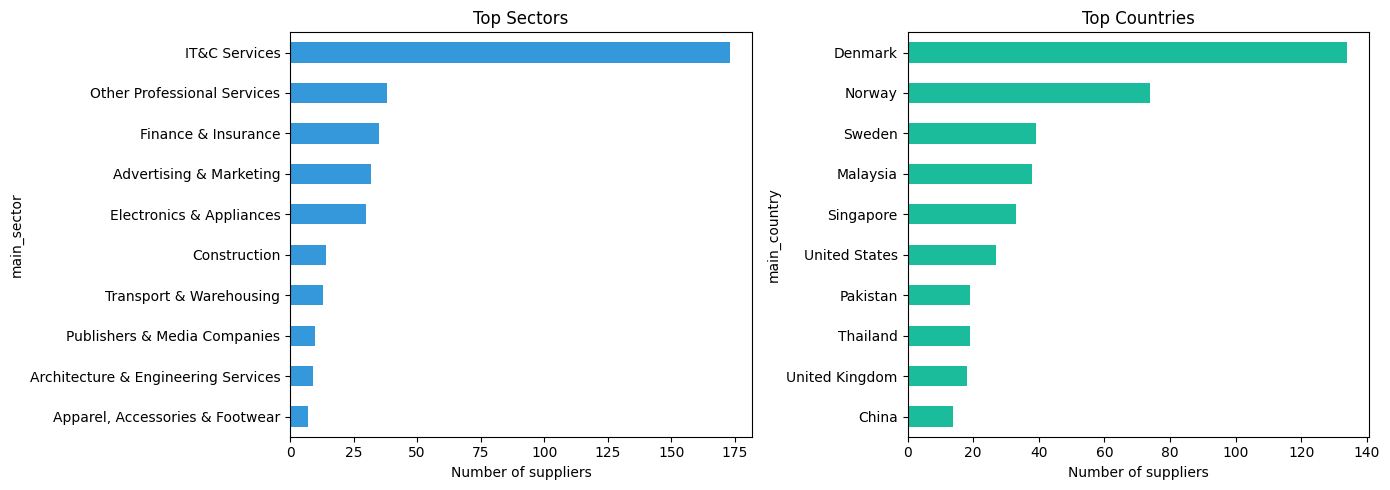


Sustainability data coverage:
  Suppliers with any sustainability mention: 86/498 (17.3%)
  That's pretty thin — the client would need Veridion's dedicated ESG data product for this


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sector distribution
sector = matched['main_sector'].value_counts().head(10)
sector.plot.barh(ax=axes[0], color='#3498db')
axes[0].set_title('Top Sectors')
axes[0].set_xlabel('Number of suppliers')
axes[0].invert_yaxis()

# country distribution
country = matched['main_country'].value_counts().head(10)
country.plot.barh(ax=axes[1], color='#1abc9c')
axes[1].set_title('Top Countries')
axes[1].set_xlabel('Number of suppliers')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# sustainability coverage
print("\nSustainability data coverage:")
esg_pattern = 'sustain|ESG|green|carbon|environment|renewable|recycl|climate'
esg_hits = matched[
    matched['business_tags'].astype(str).str.contains(esg_pattern, case=False, na=False) |
    matched['generated_business_tags'].astype(str).str.contains(esg_pattern, case=False, na=False) |
    matched['long_description'].astype(str).str.contains(esg_pattern, case=False, na=False)
]
print(f"  Suppliers with any sustainability mention: {len(esg_hits)}/{len(matched)} ({len(esg_hits)/len(matched)*100:.1f}%)")
print(f"  That's pretty thin — the client would need Veridion's dedicated ESG data product for this")

## Recommendations

**Things to fix before delivery:**
- **Phone numbers** — stored as float64, losing digits. Need to convert to string
- **Encoding** — 140+ descriptions have garbled characters, needs a UTF-8 fix  
- **Revenue outliers** — Salling Group ($10T) and Viaplay ($1.1T) are clearly wrong, flag or remove
- **Clean up** — 7 blank rows and 1 junk entry at the bottom of the working sheet

**What to highlight to the client:**
1. **Deduplication value** — we found 14 cases where different entries in their supplier list actually point to the same company. This is exactly the "cluttered, duplicate database" problem they described
2. **Enrichment** — even with a sample, we've added sector classification (86%), company descriptions (89%), and firmographic data that their raw list didn't have
3. **Revenue caveat** — only 58% of suppliers have revenue data, and modelled values are 14x lower than extracted ones. The client needs to be aware of this distinction for spend analysis
4. **Sustainability** — only 17% of suppliers have any ESG-related mentions in the current data. For their sustainability goals, Veridion's dedicated ESG data layer would be needed
5. **Match rate** — 84% on a messy, multinational dataset with rebrands, acquisitions, and address-sharing companies is a solid result